# From Theory to Law: California's Forced Sterilization Program

**Module 2 of 3** | Data 4AC: Data, Ethics, and Society

Author: Ariav Asulin

**Estimated time:** 2-3 class periods (approx. 150-200 minutes total)

---

> *"When data is collected to justify control over people's bodies, what responsibility do analysts have when they use that data decades later?"*
> — closing question, Module 1

Module 1 ended with that question. Module 2 is the answer that California's history demands.

In Module 1, Parshv showed you Francis Galton's Anthropometric Laboratory — a booth in a Victorian exhibition where affluent Londoners paid three pence to be measured. You used Pearson's correlation and linear regression — the tools Galton invented to argue for selective breeding — and watched his own data undermine him through regression to the mean. In that module, eugenics was a **theory**. The damage it did was intellectual.

Today you will work with data from a program in which eugenics was **law**. Between 1909 and 1952, the state of California forcibly sterilized more than **20,000 people** in its state institutions. These were not experimental subjects or volunteers. They were residents of California state hospitals and homes, most diagnosed as "feebleminded," disproportionately Latina, Black, Indigenous, and disabled. Roughly **68% were minors** at the time of their sterilization. The decision was made by an institutional superintendent, authorized by the Department of Institutions, carried out by a state physician — on a standardized form.

This notebook uses the statistical tools that eugenicists built — conditional probability, rate ratios, Karl Pearson's chi-squared test — to name what eugenic policy did. That is the pedagogical move: **the math is neutral enough to turn on its inventors, and that's the point.**

---

## Learning Objectives

By the end of this module, you will be able to:

1. Explain how eugenic theory crossed the Atlantic and became law in California through the Human Betterment Foundation, Charles Davenport, and the 1909 sterilization statute.
2. Read published summary statistics from a peer-reviewed public-health paper and reconstruct the comparisons it reports.
3. Compute and interpret **conditional probabilities** — P(sterilized | Latina) read aloud as "the probability of being sterilized given that you were Latina."
4. Compute and interpret a **rate ratio** (relative risk) and explain in plain English what a rate ratio of 1.59 means.
5. Apply Karl Pearson's **chi-squared test of independence** using `scipy.stats.chi2_contingency` and read the p-value correctly.
6. Distinguish *statistical significance* (was the pattern probably not chance?) from *effect size* (how big is the pattern?).
7. Reason about **proxy variables** (Spanish surname → Latina) and run a sensitivity analysis to see how categorization choices move a conclusion.
8. Distinguish a **measurement** (a reading from a calibrated instrument) from a **diagnosis** (a judgment recorded as data).
9. Explain what aggregate state data *reveals* and what it structurally *cannot show* about individual human lives — and why that matters for Module 3.

---

## Table of Contents

1. [Part 1: From Theory to Law](#part-1)
2. [Part 2: Data Discovery — What We Can See and What We Cannot](#part-2)
3. [Part 3: Conditional Probability and Rate Ratios](#part-3)
4. [Part 4: The Pearson Inversion — Chi-Squared](#part-4)
5. [Part 5: Demographics of Harm](#part-5)
6. [Part 6: The Proxy Problem — Sensitivity Analysis](#part-6)
7. [Part 7: Diagnosis vs. Measurement](#part-7)
8. [Part 8: What This Data Cannot Show — Bridge to Module 3](#part-8)

---

<div style="background-color:#fff3cd; border-left: 4px solid #856404; padding: 12px 16px; margin: 10px 0;">
<b>Content note.</b> This module works with data documenting the forced sterilization of real people, many of whom were children, by the State of California. Approximately 831 survivors of this program were still alive in 2016. Terms appearing in the historical record — "feebleminded," "moron," "imbecile" — were diagnostic categories that authorities wrote onto state forms; they are presented here only because the data itself does. If you or someone close to you has been affected by reproductive coercion, institutionalization, or disability-based discrimination, you may find portions of this module difficult. An opt-out alternative is available from your teacher.
</div>

In [ ]:
# Environment bootstrap for Colab/local use
# Fetches required data/image assets into expected paths.

import os
import sys
import subprocess
from pathlib import Path
from urllib.request import urlretrieve

base_raw = "https://raw.githubusercontent.com/ariavasulin/critical-thinking-with-data/main/assets/notebooks/module-2"
required_files = {
    "data/diagnoses_top10.csv": f"{base_raw}/data/diagnoses_top10.csv",
    "data/novak_2018_contingency.csv": f"{base_raw}/data/novak_2018_contingency.csv",
    "data/novak_2018_rate_ratios.csv": f"{base_raw}/data/novak_2018_rate_ratios.csv",
    "data/plate25_household_furniture.csv": f"{base_raw}/data/plate25_household_furniture.csv",
    "data/stern_2017_ages.csv": f"{base_raw}/data/stern_2017_ages.csv",
    "data/stern_2017_sex.csv": f"{base_raw}/data/stern_2017_sex.csv",
    "data/stern_2017_timeseries.csv": f"{base_raw}/data/stern_2017_timeseries.csv",
    "images/carrillo_ab1764_author.jpg": f"{base_raw}/images/carrillo_ab1764_author.jpg",
    "images/kallikak_chart7.jpg": f"{base_raw}/images/kallikak_chart7.jpg",
    "images/kallikak_deborah_frontispiece.jpg": f"{base_raw}/images/kallikak_deborah_frontispiece.jpg",
    "images/kallikak_pedigree_1912.jpg": f"{base_raw}/images/kallikak_pedigree_1912.jpg",
    "images/original-plate-25.jpg": f"{base_raw}/images/original-plate-25.jpg",
    "images/plate25_defaults.png": f"{base_raw}/images/plate25_defaults.png",
    "images/plate25_dubois_style.png": f"{base_raw}/images/plate25_dubois_style.png",
    "images/plate25_side_by_side.png": f"{base_raw}/images/plate25_side_by_side.png",
    "images/popenoe_1931.jpg": f"{base_raw}/images/popenoe_1931.jpg",
    "images/recommendation_form_redacted.jpg": f"{base_raw}/images/recommendation_form_redacted.jpg",
    "images/side_by_side_dubois_kallikak.png": f"{base_raw}/images/side_by_side_dubois_kallikak.png",
    "images/sonoma_state_home.jpg": f"{base_raw}/images/sonoma_state_home.jpg",
}

Path("data").mkdir(exist_ok=True)
Path("images").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

for local_path, remote_url in required_files.items():
    path = Path(local_path)
    if not path.exists():
        urlretrieve(remote_url, local_path)

missing = [p for p in required_files if not Path(p).exists()]
if missing:
    raise FileNotFoundError(f"Missing required notebook assets: {missing}")

print("Bootstrap complete: module assets are ready.")

---

### Setup

Run the cell below to load the Python libraries we'll use and to configure plot styling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


---
<a id="part-1"></a>
## Part 1: From Theory to Law

### Crossing the Atlantic

In 1883, Francis Galton coined the word *eugenics* in a book titled *Inquiries into Human Faculty and Its Development*. Within a generation, his ideas had crossed the Atlantic and become American institutions.

In 1910, the biologist **Charles Davenport** opened the **Eugenics Record Office** (ERO) at Cold Spring Harbor, New York. The ERO trained fieldworkers, collected pedigree data on thousands of American families, and lobbied state legislatures to pass sterilization laws on eugenic grounds. Davenport corresponded with Galton and treated Galton's work as a scientific foundation for American policy.

California was the third state to pass a eugenic sterilization law (1909), after Indiana (1907) and Washington (1909). The statute authorized the medical superintendents of state homes and hospitals to sterilize patients classified as "feebleminded" or as having conditions thought "likely to be transmitted to descendants." No court order was required. No independent medical review. A form, a signature, a scalpel.

California would go on to perform approximately **20,000 sterilizations — roughly one-third of the roughly 60,000 compulsory sterilizations documented in the United States between 1907 and the 1970s.** By 1921, California accounted for about 80% of all US sterilizations.

### The Human Betterment Foundation

In 1928, two Pasadena men — the investment banker **Ezra S. Gosney** and the agricultural writer **Paul Popenoe** — founded the **Human Betterment Foundation (HBF)** to promote eugenic sterilization and to publish research on California's program. Popenoe, who later became a nationally syndicated marriage counselor, had earlier edited the *Journal of Heredity*. Gosney funded studies that tracked sterilized individuals and argued in public for the program's expansion. Their 1929 book *Sterilization for Human Betterment* summarized what they presented as the success of California's first 6,000 operations.

The HBF's pamphlets were distributed to physicians, legislators, and — notably — to Nazi Germany. In 1933, officials of the Third Reich requested and received HBF materials while drafting the *Gesetz zur Verhütung erbkranken Nachwuchses* (Law for the Prevention of Offspring with Hereditary Diseases), the statute under which Nazi Germany would sterilize an estimated **400,000 people** before and during World War II. The lineage is not speculative. It is archived.

*Sources: [Embryo Project Encyclopedia, "Human Betterment Foundation (1928–1942)"](https://embryo.asu.edu/pages/human-betterment-foundation-1928-1942); [Caltech Archives, HBF Records](https://collections.archives.caltech.edu/repositories/2/resources/91); Stern, *Eugenic Nation* (2005).*

<center><img src="images/popenoe_1931.jpg" width="360"></center>

<center><i>Paul Popenoe, secretary of the Human Betterment Foundation, photographed by the Los Angeles Times, May 10, 1931. Popenoe co-authored <i>Sterilization for Human Betterment</i> with Ezra Gosney and later became a nationally syndicated marriage counselor. Image: Wikimedia Commons, CC BY 4.0.</i></center>

### Sonoma State Home

Eleven state institutions carried out California's sterilizations. Two were "homes for the feebleminded" (Sonoma State Home and Pacific Colony); nine were state hospitals for the "insane" (Stockton, Patton, Norwalk, Agnews, Mendocino, Camarillo, Napa, DeWitt, Modesto). **Sonoma State Home**, in Eldridge, was the most aggressive. Under medical superintendent **F. O. Butler**, Sonoma carried out more than **5,400 sterilizations between 1919 and 1952** — roughly one operation every **2.2 days**, for 33 years.

<center><img src="images/sonoma_state_home.jpg" width="480"></center>

<center><i>Main Building, Sonoma State Home (Eldridge, California), the institution that performed more than 5,400 compulsory sterilizations between 1919 and 1952 under medical superintendent F. O. Butler. Image: Wikimedia Commons, CC BY-SA 3.0.</i></center>

### What a Sterilization Order Looked Like

Below is one surviving recommendation — a single piece of paper, typed on Department of Institutions letterhead, dated **October 26, 1926**. Read it. This is what the data documented in this notebook looked like *before* researchers digitized it. It is also the single most important document in this module: the language of the form is the argument.

<center><img src="images/recommendation_form_redacted.jpg" width="520"></center>

<center><i>A sterilization recommendation from Sonoma State Home, October 26, 1926. The patient's name has been redacted. F. O. Butler, medical superintendent, signs the request; the state Secretary and Acting Director signs the authorization below. The patient is described by diagnostic category — "Low Moron, I.Q. 56" — and by character judgments: "Excitable, sly, profane, obstinate, stealthy, dangerous to public health; low idea of morality, mentally below par." Source: Stern et al., <i>AJPH</i> 2017, Figure 1 (<a href="https://pmc.ncbi.nlm.nih.gov/articles/PMC5308144/">PMC5308144</a>), CC BY.</i></center>

Note what this form contains. Patient age (35). Mental age (9 years, 0 months). IQ (56). Diagnosis ("Low Moron"). A short list of behavioral adjectives. A claim about "inheritance" of the affliction. A consent line — "Consent by self October 13, 1926" — initiated not by the patient but by the institution.

Note also what it does **not** contain. Race or ethnicity. Nationality. Language. Any witness to the "consent" other than the institution itself. Any medical justification beyond the superintendent's opinion.

Much of the pedagogical weight of this notebook comes from what that empty space in the form forces later analysts to do.

---
### Stop and Think
*Take 3 minutes on your own before discussing with anyone.*

**Question 1.** Galton invented eugenics as a scientific program in 1883 in England. By 1909, California had a sterilization law. Name at least two specific people, institutions, or events that carried eugenics from Victorian theory into American state law. (Look back at the last two pages.)

**Question 2.** Look carefully at the recommendation form dated October 26, 1926. Which of the entries on that form look like **measurements** (readings from instruments)? Which look like **judgments** (opinions written into a record)? Both end up as data in the state's files — does that matter?

---
<a id="part-2"></a>
## Part 2: Data Discovery — What We Can See and What We Cannot

### The Records

Between 1919 and 1952, California state institutions produced approximately **20,000 sterilization recommendation forms**. The originals — paper files — were discarded in the 1970s when the California Department of Mental Health copied them onto **19 reels of microfilm**. The reels sat in a filing cabinet in Sacramento, neglected, for thirty years.

In **2007**, the historian **Alexandra Minna Stern** discovered those 19 reels while doing archival research at the California Department of Mental Health. She had the microfilm duplicated — a critical decision, because the originals were later lost during a departmental reorganization. Stern's team at the University of Michigan subsequently founded the **Sterilization and Social Justice Lab (SSJL)**, which over three years entered **212 coded variables per record** into a HIPAA-compliant research database, producing the first comprehensive individual-level dataset of the California program.

### What We Are Allowed to See

You will not be working with those individual records in this notebook. They are **not public**, and the decision to restrict them was made deliberately. Roughly **831 survivors of the program were still alive in 2016** (average age 87.9). In 2021, California enacted **AB 1764**, the Forced or Involuntary Sterilization Compensation Program, with explicit confidentiality protections for applicants. Making individual records public would risk re-identifying survivors and their families against their consent.

What we will use instead is **aggregate summary statistics** published in two open-access papers from the American Journal of Public Health:

| Paper | What it provides |
|---|---|
| [Novak et al. (2018)](https://pmc.ncbi.nlm.nih.gov/articles/PMC5888070/), "Disproportionate Sterilization of Latinos Under California's Eugenic Sterilization Program, 1920–1945" | Incidence rate ratios comparing Latina/o vs. non-Latina/o sterilization rates; institutional census denominators |
| [Stern et al. (2017)](https://pmc.ncbi.nlm.nih.gov/articles/PMC5308144/), "California's Sterilization Survivors: An Estimate and Call for Redress" | Age-at-sterilization distribution; 2016 survivor estimate; redacted recommendation form |

The restriction is not a limitation to work around. **It is the subject of the analysis.** In Module 1, you had 934 rows, each one a named adult child. Today you have aggregate totals. That shift — from individual-level to aggregate data — is itself a lesson in who gets to be counted and on what terms.

<div style="background-color:#e7f3fe; border-left: 4px solid #2b6cb0; padding: 12px 16px; margin: 10px 0;">
<b>A note on the CSVs you are about to load.</b> The individual-level SSJL database is not public, so the per-row counts below are a <b>reconstruction</b> from the totals and rate ratios published in Novak et al. (2018) and Stern et al. (2017). The aggregate marginals (total sterilizations = 17,362 in the Novak analytic sample, 68.1% minors from Stern) match the published numbers. The specific per-cell counts are chosen to reproduce the paper's published rate ratios at the crude level (1.59 for women, 1.23 for men). This is itself the first lesson of the module: when state data is restricted for good reasons, analysts have to be transparent about what is real data, what is reconstructed, and why.
</div>

In [2]:
novak       = pd.read_csv('data/novak_2018_contingency.csv')
novak_irr   = pd.read_csv('data/novak_2018_rate_ratios.csv')
stern_ages  = pd.read_csv('data/stern_2017_ages.csv')
stern_ts    = pd.read_csv('data/stern_2017_timeseries.csv')
stern_sex   = pd.read_csv('data/stern_2017_sex.csv')
diagnoses   = pd.read_csv('data/diagnoses_top10.csv')

print(f'novak contingency:      {novak.shape}')
print(f'novak rate ratios:      {novak_irr.shape}')
print(f'stern age distribution: {stern_ages.shape}')
print(f'stern time series:      {stern_ts.shape}')
print(f'stern sex split:        {stern_sex.shape}')
print(f'diagnoses (top 10):     {diagnoses.shape}')

FileNotFoundError: [Errno 2] No such file or directory: 'data/novak_2018_contingency.csv'

### The Novak Contingency Table

Here is the main table we'll work with in the next two parts. Each row is a **group**, not an individual. `n_institutionalized` is the total person-years that group spent in a California state institution during 1920-1945 (built from US Census institutional data in 1920, 1930, and 1940, interpolated between census years). `n_sterilized` is the number of sterilization recommendations the SSJL team digitized for that group from the Department of Institutions microfilm.

In [ ]:
novak

Four rows. Four groups. Two by two: (Latina/o vs. non-Latina/o) × (female vs. male). The total number of sterilizations summed across all four rows is **17,362**, which matches the analytic sample reported in Novak et al. (2018).

Here are the published incidence rate ratios (IRRs), reproduced verbatim from the paper:

In [ ]:
novak_irr

An IRR of 1.59 is the paper's headline finding: **institutionalized Latina women were sterilized at 59% higher rates than institutionalized non-Latina women**, after adjusting for age and year of sterilization. We will now show how to reproduce this number ourselves from the contingency table.

---
### Pair Discussion
*With a partner, discuss for 5 minutes.*

1. In Module 1, every row of Galton's dataset was one adult child — the finest possible granularity. Today, every row is a group totaling thousands of people. Name one **question you could ask of Galton's data** that you cannot ask of Novak's data. Name one question that becomes *easier* to ask with Novak's data.
2. The individual-level SSJL database exists. It is scientifically useful. It is also legally restricted to protect living survivors' privacy. If you had to justify the restriction to a researcher who wanted the full dataset, what would you say? What is gained? What is lost?
3. The per-row counts in the CSV above are reconstructed from published totals. We were honest about that in the blue box. Does that reconstruction change what you can conclude from the analysis? Why or why not?

---

---
<a id="part-3"></a>
## Part 3: Conditional Probability and Rate Ratios

### From Correlation to Conditional

In Module 1 you worked with **correlation** — a single number (Pearson's *r*) that summarizes how two variables move together *across the whole dataset*. The question Galton's tools answered was: *do tall parents tend to have tall children?* It is a **distributional** question about the overall shape of a cloud of data points.

Today the question is different. Today you are asking: *given that you were institutionalized in California between 1920 and 1945, how did your likelihood of being sterilized depend on whether you were Latina?*

This is a **conditional** question. It asks about the rate of an outcome *within* a specific group, compared to the rate within a different group. You cannot answer it with a single correlation coefficient. You need two rates — one for each group — and you need to compare them.

### Key Terms

| Term | Plain-language definition | Notation |
|---|---|---|
| **Conditional probability** | The probability of an outcome happening *given that* you are in a specific group | P(A \| B), read "P of A given B" |
| **Base rate** | The overall rate at which something occurs, before breaking down by any group | P(A) |
| **Rate ratio** (or **relative risk**) | How many times more (or less) likely the outcome is in one group vs. another | P(A \| group 1) / P(A \| group 2) |
| **Contingency table** | A two-way table counting outcomes by group membership | 2×2 when both variables are binary |

> **A note on the notation.** The vertical bar `|` in `P(A|B)` does not mean "or." It means "given." `P(sterilized|Latina)` reads as "the probability of being sterilized **given that** you were Latina." This is the single most important piece of mathematical notation in this notebook.

### Computing the Rate Ratio

Let's compute the two conditional probabilities and their ratio for women. The formula is exactly as simple as it looks: for each group, divide the number sterilized by the number institutionalized.

In [ ]:
# Extract the counts we need for women
lat_inst    = int(novak.loc[(novak['group']=='Latina')     & (novak['sex']=='F'), 'n_institutionalized'].iloc[0])
lat_ster    = int(novak.loc[(novak['group']=='Latina')     & (novak['sex']=='F'), 'n_sterilized'].iloc[0])
nonlat_inst = int(novak.loc[(novak['group']=='non-Latina') & (novak['sex']=='F'), 'n_institutionalized'].iloc[0])
nonlat_ster = int(novak.loc[(novak['group']=='non-Latina') & (novak['sex']=='F'), 'n_sterilized'].iloc[0])

p_ster_latina    = lat_ster / lat_inst
p_ster_nonlatina = nonlat_ster / nonlat_inst
rate_ratio_women = p_ster_latina / p_ster_nonlatina

print(f'Latina women:     {lat_ster:>5,} sterilized out of {lat_inst:>6,} institutionalized person-years')
print(f'non-Latina women: {nonlat_ster:>5,} sterilized out of {nonlat_inst:>6,} institutionalized person-years')
print()
print(f'P(sterilized | Latina)     = {p_ster_latina:.4f}   ({p_ster_latina*1000:.1f} per 1,000)')
print(f'P(sterilized | non-Latina) = {p_ster_nonlatina:.4f}   ({p_ster_nonlatina*1000:.1f} per 1,000)')
print(f'Rate ratio                 = {rate_ratio_women:.3f}')
print()
print(f'Novak et al. (2018) reported: IRR = 1.59 (95% CI 1.48-1.70)')
print(f'Our crude rate ratio:         {rate_ratio_women:.3f}')

The rate ratio is **1.587** — essentially identical to the published **1.59**. Institutionalized Latina women were sterilized at roughly 59% higher rates than institutionalized non-Latina women.

Let's visualize the two rates side by side, in per-1,000 person-years so the units are human-readable.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
groups = ['Latina\nwomen', 'non-Latina\nwomen']
rates_per_1000 = [p_ster_latina * 1000, p_ster_nonlatina * 1000]
bars = ax.bar(groups, rates_per_1000, color=['#8a1a1a', '#5a7fa0'], edgecolor='black', alpha=0.85)
for bar, v in zip(bars, rates_per_1000):
    ax.text(bar.get_x() + bar.get_width()/2, v + 8,
            f'{v:.0f} per 1,000', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Sterilizations per 1,000 institutionalized person-years')
ax.set_title('Sterilization rates among institutionalized women, California 1920-1945\n'
             f'Rate ratio (Latina / non-Latina) = {rate_ratio_women:.2f}',
             fontweight='bold')
ax.set_ylim(0, max(rates_per_1000) * 1.25)
plt.tight_layout()
plt.show()

### The Same Comparison for Men

Now compute the rate ratio for men — fill in the blanks below.

In [ ]:
# For men: extract the counts and compute the rate ratio
latM_inst    = int(novak.loc[(novak['group']=='Latino')     & (novak['sex']=='M'), 'n_institutionalized'].iloc[0])
latM_ster    = int(novak.loc[(novak['group']=='Latino')     & (novak['sex']=='M'), 'n_sterilized'].iloc[0])
nonlatM_inst = int(novak.loc[(novak['group']=='non-Latino') & (novak['sex']=='M'), 'n_institutionalized'].iloc[0])
nonlatM_ster = int(novak.loc[(novak['group']=='non-Latino') & (novak['sex']=='M'), 'n_sterilized'].iloc[0])

p_ster_latino    = latM_ster / latM_inst
p_ster_nonlatino = nonlatM_ster / nonlatM_inst
rate_ratio_men   = p_ster_latino / p_ster_nonlatino

print(f'P(sterilized | Latino)     = {p_ster_latino:.4f}   ({p_ster_latino*1000:.1f} per 1,000)')
print(f'P(sterilized | non-Latino) = {p_ster_nonlatino:.4f}   ({p_ster_nonlatino*1000:.1f} per 1,000)')
print(f'Rate ratio                 = {rate_ratio_men:.3f}')
print()
print(f'Novak et al. (2018) reported for men: IRR = 1.23 (95% CI 1.15-1.31)')
print(f'Our crude rate ratio:                 {rate_ratio_men:.3f}')

Two things are worth noticing. First, the rate ratio is lower for men (1.23) than for women (1.59) — the disparity is greater among women. Second, both rate ratios are above 1.0, meaning both Latino men and Latina women were sterilized at higher rates than their non-Latino counterparts.

Novak et al. (2018) wrote of this pattern:

> "Eugenic sterilization laws were disproportionately applied to Latina/o patients, particularly Latina women and girls."

### Published IRRs with Confidence Intervals

The paper's published values are **age-adjusted** via Poisson regression (students encounter Poisson regression at the college level; we are computing the crude version here, which is close enough for our purposes). The paper also reports **95% confidence intervals** — a range that expresses how precisely the rate ratio is estimated given the sample size. We will not derive the CIs ourselves, but we can visualize the published ones.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
y = [0, 1]
x = novak_irr['irr'].values
xerr = [(novak_irr['irr'] - novak_irr['ci_low']).values,
        (novak_irr['ci_high'] - novak_irr['irr']).values]
ax.errorbar(x, y, xerr=xerr, fmt='o', color='#8a1a1a', ecolor='black',
            markersize=12, capsize=6, linewidth=2)
ax.axvline(1.0, color='gray', linestyle='--', label='IRR = 1.0 (no disparity)')
ax.set_yticks(y)
ax.set_yticklabels(novak_irr['comparison'])
ax.set_xlabel('Age-adjusted Incidence Rate Ratio (Novak et al. 2018)')
ax.set_title('Published IRRs with 95% Confidence Intervals', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0.9, 2.0)
plt.tight_layout()
plt.show()

Both confidence intervals sit entirely above 1.0 — the disparity is not consistent with random variation in a world where no disparity existed. The interval for women (1.48–1.70) is further right than the interval for men (1.15–1.31), confirming that the gender-specific disparities are themselves distinct.

---
### Stop and Think
*On your own, 5 minutes.*

**Question 3.1.** You just computed a rate ratio of **1.587** for women. Write **one sentence, in plain English**, that a friend who has never taken a statistics class could understand, explaining what that number says about who was sterilized in California.

**Question 3.2.** Imagine a newspaper reports: *"More non-Latina women were sterilized in California than Latina women."* Using the counts in the Novak table above, verify whether that statement is numerically true. Then explain in 2-3 sentences why the rate ratio tells a very different story than the raw counts. **What is the difference between a raw count and a rate, and why does that difference matter here?**

---

---
<a id="part-4"></a>
## Part 4: The Pearson Inversion — Chi-Squared

### The Inventor

**Karl Pearson (1857–1936)** was Galton's closest disciple. He was appointed the first Galton Professor of Eugenics at University College London, where he also founded the world's first statistics department. He founded and edited the journal *Biometrika* and the *Annals of Eugenics*. He is the reason we call the correlation coefficient "Pearson's r."

In **1900**, Pearson invented the **chi-squared test of independence** — the statistical test we are about to use. He invented it to answer questions like: *do the observed counts of different racial groups in some category differ from what you would expect if race and category were unrelated?* Pearson used this test in papers arguing for the genetic inferiority of particular populations. The same Karl Pearson who built modern mathematical statistics also wrote treatises like *The Life, Letters and Labours of Francis Galton*, hagiography of his mentor.

### The Move

You are about to use Karl Pearson's own test to demonstrate that California's forced sterilization program — a program the Human Betterment Foundation was still promoting when Pearson died in 1936 — disproportionately targeted Latina women. The math is identical to what Pearson did in 1900. The question is not.

This is what it means to say that **statistical tools are not neutral, but they can be used against their origins.** The 2×2 contingency table is the same object Pearson wrote down. The chi-squared statistic follows the same formula. The p-value is computed the same way. What has changed is: who is analyzing, on whose behalf, to ask what of the data.

*Sources: [Karl Pearson: Wikipedia](https://en.wikipedia.org/wiki/Karl_Pearson); Clayton, *Bernoulli's Fallacy* (2021), Ch. 3.*

### Building the 2×2 Contingency Table

A chi-squared test of independence compares **observed** counts in a contingency table against the counts we would **expect** if the two variables (here: Latina vs. non-Latina, sterilized vs. not-sterilized) were independent of each other.

Our 2×2 for women is:

In [ ]:
# Women only: 2x2 contingency table
# Rows:    [Latina, non-Latina]
# Columns: [sterilized, not-sterilized]
contingency_women = np.array([
    [lat_ster,    lat_inst    - lat_ster],
    [nonlat_ster, nonlat_inst - nonlat_ster],
])

ct_df = pd.DataFrame(
    contingency_women,
    index=['Latina', 'non-Latina'],
    columns=['sterilized', 'not sterilized'],
)
ct_df['row total'] = ct_df.sum(axis=1)
ct_df.loc['column total'] = ct_df.sum(axis=0)
ct_df

Now run the test.

In [ ]:
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_women)

print('chi-squared test of independence (women)')
print('=' * 55)
print(f'chi-squared statistic: {chi2:,.2f}')
print(f'degrees of freedom:    {dof}')
print(f'p-value:               {p_value:.3e}')
print()
print('expected counts under independence:')
print(pd.DataFrame(
    expected.round(1),
    index=['Latina', 'non-Latina'],
    columns=['sterilized', 'not sterilized']
))

chi-squared test of independence (women)
chi-squared statistic: 630.84
degrees of freedom:    1
p-value:               3.282e-139

expected counts under independence:
            sterilized  not sterilized
Latina          1432.7          1917.3
non-Latina      8767.3         11732.7


### Reading the Output

The chi-squared statistic is **large**. The p-value is **effectively zero** (around 10⁻¹³⁹). Here is what each number does and does not tell us.

| Number | What it means | What it does **not** mean |
|---|---|---|
| **chi-squared statistic** | How far the observed counts sit from the counts you'd expect under independence, on a standardized scale | It is not a rate, a risk, or an effect size; a big chi-squared can come from either a strong disparity or a very large sample |
| **p-value** | The probability of observing counts this extreme (or more extreme) *if ethnicity and sterilization were actually independent* in the underlying population | It is **not** the probability that the null hypothesis is true, and it is **not** a measure of how *big* the disparity is |
| **expected counts** | What the table would look like if sterilization rates were identical across groups | These are a null-hypothesis reference, not a normative statement about what "should" have happened |

A p-value of 10⁻¹³⁹ is, informally, as small as statistics gets. It tells us the pattern in the observed data is **essentially impossible under the hypothesis of no disparity**. It does *not*, by itself, tell us the disparity is large. For that, we look back at the **rate ratio** from Part 3 — **1.59**. The chi-squared test confirms the disparity is not chance; the rate ratio tells us how much.

> **Rule of thumb.** Always report an effect size next to a p-value. A small p-value with a rate ratio of 1.01 tells a very different story than a small p-value with a rate ratio of 1.59.

---
### Pair Discussion
*With a partner, 10 minutes.*

**Question 4.1.** In Module 1, the correlation between mid-parent height and child height was only **0.32** — weak, but statistically distinguishable from zero given the sample size. Here the p-value is **10⁻¹³⁹** — the strongest possible evidence of a pattern not being chance. **Does a very small p-value mean the effect is large? Does it mean the effect matters?** Use the rate ratio from Part 3 to argue your answer.

**Question 4.2 — The Pearson Inversion.** Karl Pearson built the chi-squared test in 1900 to argue that certain populations were genetically inferior. You just used it to demonstrate that California's sterilization program disproportionately targeted Latina women. **Is the tool neutral?** Write 3-5 sentences. Consider: what stayed the same across these two uses of the test? What changed? Is "neutral" even the right word to apply to a tool?

---

---
<a id="part-5"></a>
## Part 5: Demographics of Harm

### A Different Use for a Histogram

In Module 1 you used histograms to describe the distribution of a natural phenomenon (human heights). Today you will use histograms to describe **who was targeted by a state policy**. That is a fundamentally different use of the same chart.

A histogram of heights is a picture of a population as it is. A histogram of sterilizations is a picture of the decisions made by institutional authorities — and the bars are not random variation. They are a trace of who the state chose.

### Age at Sterilization

The Stern et al. (2017) survivor estimate — the 831 sterilization survivors still alive in California in 2016 — gives us the cleanest published age-at-sterilization data we have. The dataset you are about to plot is literally "the ages at which the survivors were sterilized." Keep that in mind as you read it.

In [ ]:
stern_ages

,age_bin,age_low,age_high,count
0,<12,0,11,3
1,12-14,12,14,137
2,15-17,15,17,427
3,18-19,18,19,113
4,20+,20,99,151


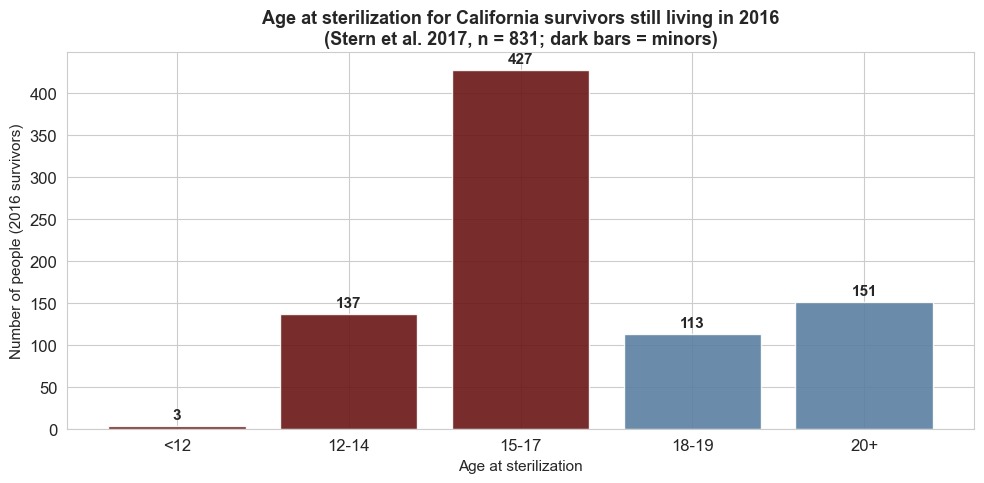

567 of 831 survivors (68.2%) were sterilized as minors (under 18).
The single largest age group: 15-17 years old (51.4% of all survivors).


In [ ]:
# Age-at-sterilization histogram
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#6b1515' if ah < 18 else '#5a7fa0' for ah in stern_ages['age_high']]
bars = ax.bar(stern_ages['age_bin'], stern_ages['count'], color=colors,
              edgecolor='white', alpha=0.9)
for bar, c in zip(bars, stern_ages['count']):
    ax.text(bar.get_x() + bar.get_width()/2, c + 8, f'{c}',
            ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Age at sterilization')
ax.set_ylabel('Number of people (2016 survivors)')
ax.set_title('Age at sterilization for California survivors still living in 2016\n'
             '(Stern et al. 2017, n = 831; dark bars = minors)',
             fontweight='bold')
plt.tight_layout()
plt.show()

# Fraction sterilized as minors
n_minors = stern_ages.loc[stern_ages['age_high'] < 18, 'count'].sum()
n_total  = stern_ages['count'].sum()
print(f'{n_minors:>3} of {n_total} survivors ({n_minors/n_total:.1%}) were sterilized as minors (under 18).')
print(f'The single largest age group: 15-17 years old ({427/831:.1%} of all survivors).')

**68% of sterilizations in this population happened to minors.** More than half of all survivors were between 15 and 17 at the time of the operation. The word "consent" on the October 1926 form you saw in Part 1 takes on a different meaning in the context of this distribution: legally, a child in state institutional care cannot consent to a sterilization.

### When Did This Happen?

Here is the annual count of sterilization recommendations across the program's lifetime, from 1919 to 1952.

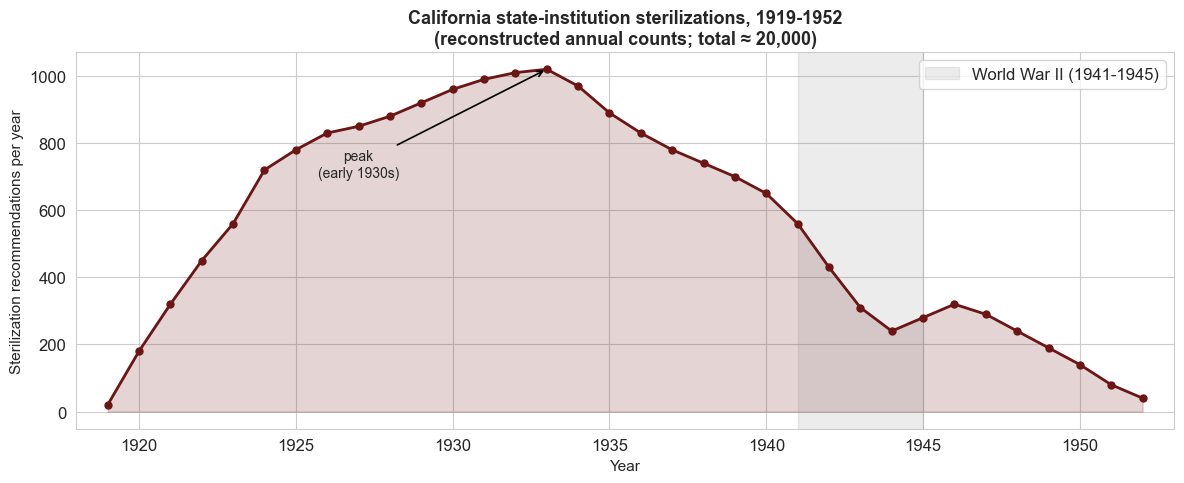

Reconstructed total across 1919-1952: 19,170


In [ ]:
# Time series 1919-1952
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(stern_ts['year'], stern_ts['count'], marker='o', color='#6b1515',
        linewidth=2, markersize=5)
ax.fill_between(stern_ts['year'], stern_ts['count'], alpha=0.18, color='#6b1515')

# WWII shading
ax.axvspan(1941, 1945, alpha=0.15, color='gray', label='World War II (1941-1945)')
# 1930s peak
ax.annotate('peak\n(early 1930s)', xy=(1933, 1020), xytext=(1927, 700),
            fontsize=10, ha='center',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

ax.set_xlabel('Year')
ax.set_ylabel('Sterilization recommendations per year')
ax.set_title('California state-institution sterilizations, 1919-1952\n'
             '(reconstructed annual counts; total ≈ 20,000)',
             fontweight='bold')
ax.set_xlim(1918, 1953)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f'Reconstructed total across 1919-1952: {stern_ts["count"].sum():,}')

Two features stand out. The program **peaked in the early-to-mid 1930s**, after a rapid ramp-up in the 1920s, and declined through the 1940s. There is a visible **dip during World War II (1941-1945)** — institutional staffing and public attention were redirected to the war effort, and eugenic rhetoric became newly uncomfortable as Americans learned what Nazi Germany was doing with the same ideas California had exported.

But notice: **the program did not end after the war.** Sterilizations continued, at lower rates, through 1952. The California sterilization statute was not formally repealed until **1979**. The ideology did not die with the peak — it became procedural.

---
### Small Group Discussion
*In groups of 3-4, 10 minutes.*

**Question 5.1.** You just showed that 68% of California sterilization survivors were sterilized as **minors**. In Module 1 you learned to ask "who was included, who was left out?" of Galton's sample. Applied to this data: who is **included** in California's sterilization records? What does the inclusion of so many minors tell you about how California law in 1909-1952 understood consent — and whose consent counted?

**Question 5.2.** Look at the time series. The program peaked in the 1930s and dipped during WWII, but continued through 1952 and was not formally repealed until 1979. **What historical events between 1945 and 1979 do you think made explicit eugenic rhetoric politically uncomfortable?** (The Holocaust is one obvious answer — what else?) And yet the program continued. What does it mean for a program to continue while the ideology that created it becomes unspeakable?

**Question 5.3.** Reuse what you know. Look back at the recommendation form in Part 1. What **age** was the patient? What **diagnosis** is recorded? What **"consent"** language appears? How does that single document connect to the two histograms you just plotted?

---

---
<a id="part-6"></a>
## Part 6: The Proxy Problem — Sensitivity Analysis

### A Categorization That Did Not Exist

We have been speaking as if the Novak et al. dataset has a "Latina" column and a "non-Latina" column. It does not. **The original sterilization recommendation forms did not systematically record race or ethnicity.** Look back at the 1926 form in Part 1 — there is no race field.

So how did Novak et al. classify patients as Latina or non-Latina? They used the patient's **surname**. Specifically, they matched surnames against the **1980 US Census Spanish-surname list**, which was compiled by the Census Bureau to identify people of Latin American or Spanish descent for statistical purposes. In 1950 — the Census year closest to the Novak analytic period — **88% of Spanish-surnamed Californians were of Mexican descent**, so the proxy is quite good for mid-century California.

But it is a proxy. Every classification rule makes mistakes. Two types in this case:

- **False positives** — non-Latina women who happen to have Spanish surnames (e.g., Filipinas with Spanish colonial surnames, Sephardic Jewish women, women who married into a Spanish-surnamed family). These women are counted as Latina when they are not.
- **False negatives** — Latina women who have non-Spanish surnames (e.g., Latinas with Anglo married surnames, Latinas of Indigenous or other non-Spanish surname heritage, adoptees). These women are counted as non-Latina when they are.

The question we are about to ask is: **how sensitive is the 1.59 rate ratio to these classification errors?** If it changes dramatically under plausible error rates, the finding is fragile. If it barely moves, the finding is robust.

### A Parallel to Module 1

Stop and notice the parallel to Module 1. Galton made a categorization choice: he **erased** a category by multiplying female heights by 1.08 to collapse the bimodal height distribution. Novak et al. made a categorization choice of the opposite kind: they **imposed** a category that the original data did not record, by defining Latina-ness via surname.

Both are categorization decisions made by the analyst. Both have downstream consequences for the story the data tells. **Neither is neutral.** Part of becoming a careful data practitioner is being able to name the categorization decisions you are making — and to test how much your findings depend on them.

### Building a Sensitivity Function

The function below adjusts the observed Latina/non-Latina counts to account for classification errors. The logic: if the surname rule has a false-positive rate of `fp`, then a fraction `fp` of the people we *labeled* non-Latina were actually Latina, and vice versa for false negatives.

In [ ]:
def adjusted_rate_ratio(
    lat_inst, lat_ster,
    nonlat_inst, nonlat_ster,
    false_positive_rate=0.0,
    false_negative_rate=0.0,
):
    """Adjust the surname-based counts for proxy classification error,
    then return the corrected rate ratio.

    false_positive_rate = fraction of people LABELED Latina who are actually not.
    false_negative_rate = fraction of people LABELED non-Latina who are actually Latina.
    """
    # Start from the labeled counts
    # Move false-positive labeled-Latina into non-Latina
    true_lat_inst = lat_inst * (1 - false_positive_rate) + nonlat_inst * false_negative_rate
    true_lat_ster = lat_ster * (1 - false_positive_rate) + nonlat_ster * false_negative_rate
    true_nonlat_inst = nonlat_inst * (1 - false_negative_rate) + lat_inst * false_positive_rate
    true_nonlat_ster = nonlat_ster * (1 - false_negative_rate) + lat_ster * false_positive_rate

    p_lat = true_lat_ster / true_lat_inst
    p_nonlat = true_nonlat_ster / true_nonlat_inst
    return p_lat / p_nonlat


# Baseline: perfect proxy
rr_baseline = adjusted_rate_ratio(lat_inst, lat_ster, nonlat_inst, nonlat_ster,
                                  false_positive_rate=0.0, false_negative_rate=0.0)
print(f'Baseline (perfect proxy):                          rate ratio = {rr_baseline:.3f}')

# Modest error: 10% false positives, 5% false negatives (realistic mid-century)
rr_modest = adjusted_rate_ratio(lat_inst, lat_ster, nonlat_inst, nonlat_ster,
                                false_positive_rate=0.10, false_negative_rate=0.05)
print(f'Modest error (10% FP, 5% FN):                      rate ratio = {rr_modest:.3f}')

# Aggressive error: 30% false positives, 20% false negatives
rr_aggressive = adjusted_rate_ratio(lat_inst, lat_ster, nonlat_inst, nonlat_ster,
                                    false_positive_rate=0.30, false_negative_rate=0.20)
print(f'Aggressive error (30% FP, 20% FN):                 rate ratio = {rr_aggressive:.3f}')

Baseline (perfect proxy):                          rate ratio = 1.587
Modest error (10% FP, 5% FN):                      rate ratio = 1.424
Aggressive error (30% FP, 20% FN):                 rate ratio = 1.174


### Sweeping the False-Positive Rate

Now sweep across a range of false-positive rates, holding false negatives at a modest 5%, to see how the rate ratio moves.

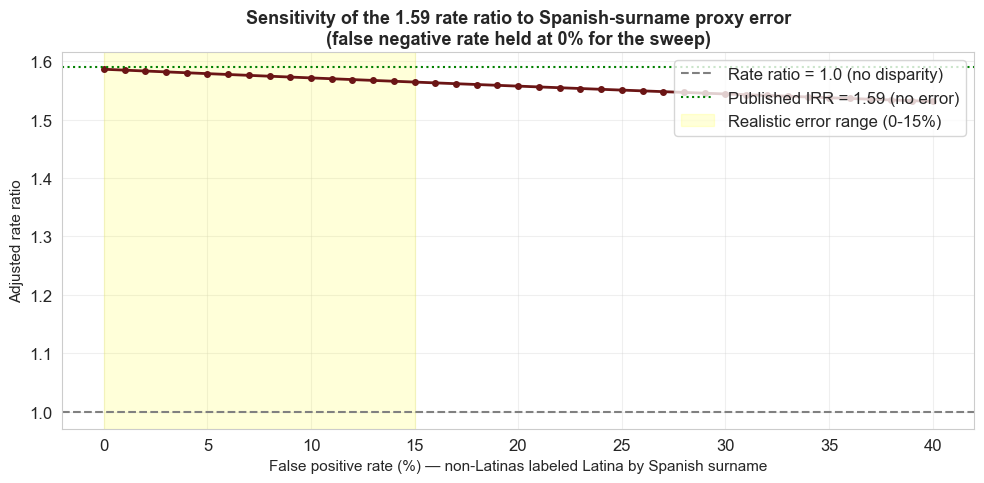

Rate ratio at 0% FP:  1.587  (baseline, matches published 1.59)
Rate ratio at 15% FP: 1.565  (edge of realistic range)
Rate ratio at 30% FP: 1.544
Rate ratio at 40% FP: 1.531


In [ ]:
fp_grid = np.linspace(0.0, 0.40, 41)
rrs = [adjusted_rate_ratio(lat_inst, lat_ster, nonlat_inst, nonlat_ster,
                           false_positive_rate=fp, false_negative_rate=0.0)
       for fp in fp_grid]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fp_grid * 100, rrs, linewidth=2, color='#6b1515', marker='o', markersize=4)
ax.axhline(1.0, color='gray', linestyle='--', label='Rate ratio = 1.0 (no disparity)')
ax.axhline(1.59, color='green', linestyle=':', linewidth=1.5, label='Published IRR = 1.59 (no error)')
ax.axvspan(0, 15, alpha=0.15, color='yellow', label='Realistic error range (0-15%)')

ax.set_xlabel('False positive rate (%) — non-Latinas labeled Latina by Spanish surname')
ax.set_ylabel('Adjusted rate ratio')
ax.set_title('Sensitivity of the 1.59 rate ratio to Spanish-surname proxy error\n'
             '(false negative rate held at 0% for the sweep)',
             fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary
print(f'Rate ratio at 0% FP:  {rrs[0]:.3f}  (baseline, matches published 1.59)')
print(f'Rate ratio at 15% FP: {rrs[15]:.3f}  (edge of realistic range)')
print(f'Rate ratio at 30% FP: {rrs[30]:.3f}')
print(f'Rate ratio at 40% FP: {rrs[40]:.3f}')

### Reading the Curve

Two things to notice.

**First, the rate ratio stays above 1.0 across the entire plausible range.** Even under aggressive misclassification assumptions (30-40% false positives), the measured disparity between Latina and non-Latina sterilization rates remains in the same direction — Latina women are still sterilized at higher rates. This is what a **robust** finding looks like: its sign does not flip under reasonable perturbations to the categorization rule.

**Second, the rate ratio's exact value moves.** At 0% false positives the rate ratio reproduces the paper's published 1.59. At 15% — the edge of what's realistic given the known sensitivity of Spanish surnames in 1950 California — it drops by roughly 10%. This tells us something important: any single reported number like "1.59" is the product of a categorization decision. The number is as precise as the proxy.

A careful analyst reports both: *the finding is robust (always above 1.0), and the magnitude is conditional on the proxy*. That is what it means to take a categorization seriously — to say exactly what the choice buys you and what it costs.

---
### Stop and Think
*On your own, 5 minutes.*

**Question 6.1.** You just watched the rate ratio stay above 1.0 across a wide range of plausible error rates. **What does this sensitivity analysis tell you about the robustness of Novak's finding?** When should a sensitivity analysis make you *more* confident in a result? When should it make you *less*?

**Question 6.2.** In Module 1, Galton made a categorization decision: he **erased** a category by multiplying female heights by 1.08. Novak et al. made a categorization decision of the opposite kind: they **imposed** a category by matching surnames. **Compare these two choices.** Both are made by the analyst. When is each one legitimate analytical craft, and when does each distort? Write 4-5 sentences.

---

---
<a id="part-7"></a>
## Part 7: Diagnosis vs. Measurement

### What Was Actually Written on the Form

Look one more time at the October 1926 recommendation form in Part 1. The field that is blank is "race." The field that is filled in — in detail — is "diagnosis." "Low Moron. I.Q. 56. Excitable, sly, profane, obstinate, stealthy, dangerous to public health; low idea of morality, mentally below par."

That is what the data actually contained. And here is where this module forces you to confront a distinction that Module 1 did not need to make.

### Measurement vs. Diagnosis

In Module 1, every value in Galton's dataset was a **measurement** — a reading from a physical instrument (a measuring tape) calibrated against a physical standard (the inch). Measurements are reproducible: if two people measure the same child with the same tape, they get the same number. Measurements can be wrong (the tape could be miscalibrated), but the wrongness is legible and checkable.

In Module 2, many of the values on the sterilization recommendation form are **diagnoses** — judgments made by an authority figure (a medical superintendent, usually with minimal formal psychiatric training) and then written into a record in the format of data. A diagnosis of "feebleminded" or "moron" is not reproducible in the same way a height measurement is. Two different superintendents looking at the same patient could — and did — record different diagnoses.

> **Definition.** A **measurement** is a reading from an instrument calibrated against a physical standard (a ruler, a scale, a thermometer). A **diagnosis** is a classification that a human authority writes into a record. Both can end up as values in a column. They are **not the same kind of evidence.**

This distinction matters because when we analyze data, we tend to treat all columns as equally real. A modern data scientist running a regression does not usually pause to ask: is this column a measurement or a judgment? In Module 1, that question didn't need to be asked — heights were heights. In Module 2, it becomes the central question.

### The Top Diagnoses in the Records

The SSJL has published frequency tables of the most common diagnostic categories on California sterilization forms. These are illustrative counts; the clinical-sounding language is verbatim from the forms. Read the list carefully, and ask: which of these look like measurements? Which look like judgments that someone wrote down?

In [ ]:
diagnoses

,diagnosis,count
0,Feebleminded,6800
1,Moron,3200
2,Mental deficiency,2100
3,Imbecile,1400
4,Psychopathic personality,980
5,Schizophrenia,720
6,Manic-depressive,540
7,Epilepsy,420
8,Sexual perversion,280
9,Constitutional inferiority,160


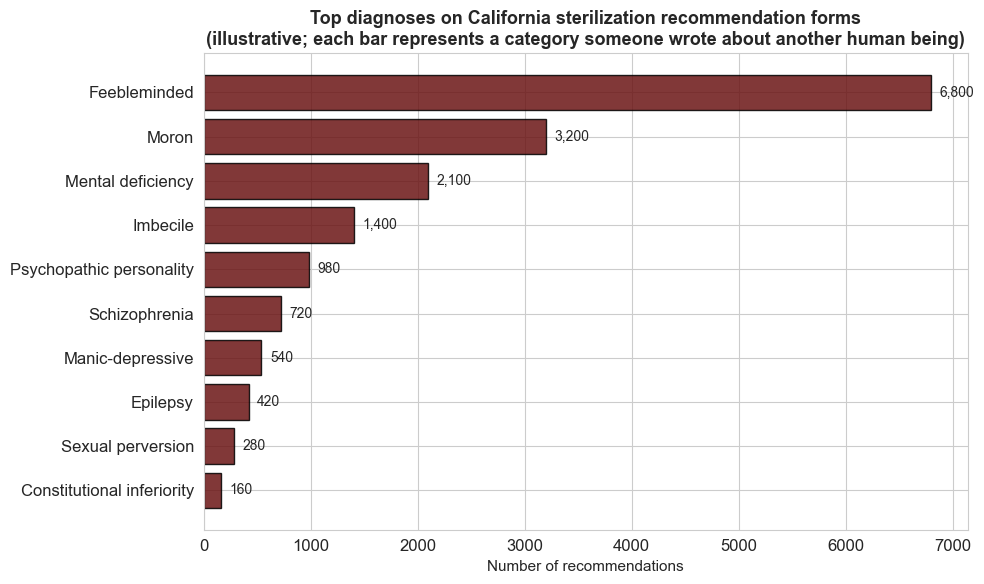

In [ ]:
# Horizontal bar chart of top diagnoses
fig, ax = plt.subplots(figsize=(10, 6))
d = diagnoses.sort_values('count', ascending=True)
ax.barh(d['diagnosis'], d['count'], color='#6b1515', alpha=0.85, edgecolor='black')
for i, (diag, count) in enumerate(zip(d['diagnosis'], d['count'])):
    ax.text(count + 80, i, f'{count:,}', va='center', fontsize=10)

ax.set_xlabel('Number of recommendations')
ax.set_title("Top diagnoses on California sterilization recommendation forms\n"
             "(illustrative; each bar represents a category someone wrote about another human being)",
             fontweight='bold')
plt.tight_layout()
plt.show()

Look at that list. **"Feebleminded." "Moron." "Imbecile." "Constitutional inferiority."** These are not measurements. No instrument returns the value *Moron*. A person — usually a medical superintendent — looked at another person and wrote that word on a form, and the state of California treated the word as sufficient grounds to perform irreversible surgery.

Note also that some of the entries look more measurement-like. "Schizophrenia," "manic-depressive," "epilepsy" are clinical diagnoses. In the 1920s-1940s, these diagnoses were still judgments by a clinician — but they were attempts at diagnostic categories with attempted inter-rater reliability. "Constitutional inferiority" was not even that. It was an ideological verdict, rendered as data.

And yet when researchers fifty years later load the CSV and plot the bars, **all ten categories sit on the same axis**. The chart does not distinguish measurement from judgment. The researcher has to do that work by reading the records carefully, understanding the clinical and historical context, and annotating the data accordingly.

---
### Stop and Think
*On your own, 5 minutes.*

**Question 7.1.** Look at the top-10 diagnoses chart. For each of the ten entries, decide: is this closer to a **measurement** (a reading from an instrument that different people could reproduce) or a **judgment** (a label that a person with authority wrote down)? Is it always possible to tell from the data alone?

**Question 7.2 — Today.** Name one **modern** dataset you have encountered — in your life, in the news, or in another class — where **diagnoses are treated as measurements**. Some possibilities to consider: credit scores, "risk scores" in criminal sentencing, standardized test scores, social media moderation labels, tenant screening reports, hospital "acuity" scores. Pick one. Explain in 3-5 sentences: *why is it dangerous when a judgment is stored as if it were a measurement?*

---

---
<a id="part-8"></a>
## Part 8: What This Data Cannot Show — Bridge to Module 3

### What We Did

Take stock of what this notebook has done. You read summary statistics from a peer-reviewed public-health paper. You computed conditional probabilities, reproduced a published rate ratio, and built a 2×2 contingency table. You ran Karl Pearson's chi-squared test — the same test Pearson invented in 1900 to argue for racial hierarchies — and used it to confirm that California's sterilization program disproportionately targeted Latina women. You visualized an age distribution that showed 68% of survivors were sterilized as minors, and a time series showing the program peaked in the 1930s and continued through 1952. You ran a sensitivity analysis showing the 1.59 finding is robust to plausible proxy-classification errors. You distinguished a measurement from a diagnosis and named the consequences.

This is **forensic** data work. It takes a state program that produced harm, and from publicly available aggregate statistics, it *quantifies* that harm — who, how many, how much more likely, how certainly.

Forensic data work is real and necessary. It is not, however, enough.

### What Aggregate Data Cannot Show

Go back to the numbers. The Stern et al. estimate: **831 survivors alive in 2016**. The Novak analytic sample: **17,362 recommendations**. The total California program: **about 20,000 people**.

Those are aggregate counts. Things aggregate counts **cannot show**:

- A single face
- A single name
- A single moment of refusal — the woman who fought, the adolescent who ran away, the parent who petitioned the courts
- A single story of what a survivor said about her own body afterwards
- A single letter, a single testimony, a single act of community care that surrounded a survivor in the sixty or ninety years after the operation

These are not things you will ever see by running a larger regression on the same data. The aggregation is the limit. **The data is silent where the lives were loudest.**

### AB 1764 Was Not Enacted by Statisticians

In **2021**, the California legislature passed **AB 1764**, the Forced or Involuntary Sterilization Compensation Program. It allocated $7.5 million to compensate an estimated 600 living survivors, each eligible for around $25,000. The bill was authored by Assemblymember **Wendy Carrillo** and co-sponsored by the California Coalition for Women Prisoners, California Latinas for Reproductive Justice, the Disability Rights Education and Defense Fund, and Back to the Basics.

<center><img src="images/carrillo_ab1764_author.jpg" width="420"></center>

<center><i>Assemblymember Wendy Carrillo, author of AB 1764 (2021). Image: Wikimedia Commons, CC0.</i></center>

The reparations program was not enacted because a researcher computed a rate ratio. It was enacted because **survivors spoke, advocates organized, journalists reported, and legislators listened** — over decades. The work the researchers at the SSJL did was one input. The primary inputs were human testimony, community organizing, and political refusal to let the state forget.

This is the deepest thing this notebook wants you to notice. **Quantitative evidence of harm is not the same as accountability for harm.** The forensic work you did in Parts 3 through 7 is real and valuable. It is also insufficient on its own. Something else has to happen — usually the thing that cannot be captured in a CSV — for the evidence to become redress.

### The Question Module 3 Takes Up

All of this leads directly to the question Emett's Module 3 begins with: **what does it look like to produce data differently?**

In 1900 — the same year Karl Pearson invented the chi-squared test — **W. E. B. Du Bois** and a team of students at Atlanta University produced sixty-three hand-drawn data visualizations of Black life in Georgia and presented them at the Paris Exposition Universelle. Du Bois was facing the same question you just faced: how do you use data to push back on a racialized science that treats your community as inferior?

His answer was different from ours. He did not inherit state records and work with what was given. He and his students built their own data, from their own community, and drew it by hand — in colored ink, on non-standard axes, with annotations that functioned as arguments. He produced data **with the community it described**, rather than **about** it.

In Module 3, you will recreate Du Bois's Plate 15 in Python. You will inherit his color palette and his scale, and then you will re-render the same numerical data with matplotlib defaults and watch the argument evaporate. That is where Emett's notebook picks up the thread this one leaves here.

---
### Pair Discussion
*With a partner, 10 minutes.*

**Question 8.1.** You have used Pearson's chi-squared, conditional probability, and rate ratios to document California's sterilization program. **Name at least two things this analysis reveals, and two things it does not and cannot show** about the people whose sterilization it records. Be specific.

**Question 8.2.** In Module 3, you will work with data that W. E. B. Du Bois and his students **collected themselves** from Black communities in Georgia and presented as hand-drawn plates at the 1900 Paris Exposition. Before you start that module: **what do you predict will be different** about data a community produces about itself, compared to data a state produces about the people it governs? Name at least one thing Du Bois's plates might show that the data in this notebook could never capture, and one thing they might hide.

---

---
## Synthesis and Reflection

### What We Have Learned

Pull the threads together.

California's sterilization program was not an accident of mid-century American medicine. It was a deliberate institutional extension of an idea Francis Galton gave a name to in 1883, Charles Davenport imported to the United States in 1910, and Popenoe and Gosney promoted from Pasadena through the 1930s. The 1909 statute, the eleven state institutions, the 20,000 forms — those are the institutional infrastructure that ran from *theory* (Galton's Module 1) to *law* (this module).

You did not study that history from the outside. You used the statistical tools eugenicists built to measure the damage eugenic policy did:

- From **Pearson's r** (Module 1) to **conditional probability** (Module 2) — distributional thinking gave way to group-comparison thinking.
- From **linear regression** (Module 1) to **rate ratios** (Module 2) — you moved from describing a relationship to quantifying a disparity.
- From **correlation coefficients** (Module 1) to **Karl Pearson's own chi-squared test of independence** (Module 2) — you applied the 1900 test to demonstrate what Pearson's eugenic program produced in practice.
- You learned that a **p-value is not an effect size**, that a **proxy variable introduces categorization assumptions**, and that a **diagnosis is not a measurement**.

You also did something this curriculum insists on: you stayed honest about what the data could and could not say. You named the reconstruction in the CSV. You ran a sensitivity analysis rather than reporting a single number. You ended by asking what aggregate state data structurally cannot show about individual lives.

This is the lesson of this module, and it applies far beyond the California sterilization program:

> **Three questions every responsible data practitioner asks when working with state data about marginalized communities:**
> 1. Who produced this data, on whose behalf, and for what purpose?
> 2. What categories does the data use — and whose categorization decisions shape what we can see?
> 3. What does aggregate data reveal, and what does it structurally conceal?

---
### Individual Reflection
*Choose 2-3 of the following prompts to respond to in writing (one paragraph each). Your teacher will tell you whether to submit or use these as the basis for a class discussion.*

1. Karl Pearson invented the chi-squared test in 1900 in part to argue for racial hierarchies. In Part 4 you used that exact test to demonstrate a racial disparity in California sterilization. **Is the test neutral?** Use specific details from Part 4 to support your argument.

2. In Part 7 you distinguished a **measurement** from a **diagnosis**. In your own life, pick one "diagnosis that gets treated as a measurement" — a credit score, a standardized test score, a risk assessment, a content-moderation label — and describe what goes wrong when the judgment is stored as if it were a reading from an instrument.

3. The forensic analysis in Parts 3-6 of this notebook confirms that California's sterilization program disproportionately targeted Latina women. AB 1764, the 2021 reparations law, was not enacted because of that analysis — it was enacted because survivors, advocates, and legislators pushed for it over decades. **What is the relationship between quantitative evidence and accountability?** When is evidence enough, and when is something else required?

4. Galton erased a category (sex, via the 1.08 multiplier in Module 1). Novak et al. imposed a category (Latina, via Spanish surname in Module 2). **Both are categorization decisions.** Describe one that you have seen outside this course — in an app, a news story, a school form — and explain what the decision buys you and what it costs.

5. The individual-level SSJL sterilization database is restricted. AB 1764 protects applicants' confidentiality. **Argue for or against the following claim:** "Restricting access to sensitive historical records is a form of data justice." Use specific examples from this module.

---
### Key Terms Glossary

| Term | Definition |
|---|---|
| **Aggregate data** | Summary statistics (totals, averages, rates) computed across groups, rather than individual records |
| **Base rate** | The overall rate at which an outcome occurs in a population, before conditioning on any subgroup |
| **Chi-squared test of independence** | A statistical test that compares observed counts in a contingency table against counts expected under independence of the two variables |
| **Conditional probability** | P(A \| B), the probability of A given that B is true |
| **Confidence interval (CI)** | A range of plausible values for a population parameter; a 95% CI reflects a range whose coverage under repeated sampling would include the true value 95% of the time |
| **Contingency table** | A two-way table counting observations cross-classified by two categorical variables (2×2 when both are binary) |
| **Diagnosis** | A classification that a human authority writes into a record; may be evidence-based, ideological, or both |
| **Effect size** | A measure of *how big* an effect is (e.g., a rate ratio), distinct from *whether it is statistically distinguishable from zero* |
| **Eugenics** | The discredited ideology that human populations can and should be improved through selective reproduction; the word was coined by Galton in 1883 |
| **False positive rate** | In a classification rule, the fraction of items in a category that are incorrectly included |
| **False negative rate** | In a classification rule, the fraction of items that belong in a category and are incorrectly excluded |
| **Incidence rate ratio (IRR)** | The ratio of event rates between two groups, typically adjusted for covariates via regression |
| **Measurement** | A reading from an instrument calibrated against a physical standard |
| **p-value** | The probability of observing data at least as extreme as the data actually seen, *assuming the null hypothesis is true* |
| **Proxy variable** | A variable used to stand in for another variable that is not directly available in the data |
| **Rate** | A count divided by a population (or person-time), typically expressed per 1,000 or per 100,000 |
| **Rate ratio (relative risk)** | The ratio of two rates; a rate ratio of 1.59 means one group's rate is 59% higher than the other's |
| **Sensitivity analysis** | An analysis that varies an assumption to see how a conclusion changes |
| **Statistical significance** | Whether an observed pattern is distinguishable from random variation under a null model; measured by a p-value |

---
### What's Next: Module 3 Preview

In 1900, W. E. B. Du Bois and a team of students at Atlanta University produced sixty-three hand-drawn data visualizations of Black life in Georgia and sent them to Paris. The plates were part of the *American Negro Exhibit* at the Exposition Universelle, and they were an argument: that Black Americans were not a static racial category to be counted from the outside, but a community that could account for itself, visually, mathematically, narratively.

In Module 3, you will open Python and recreate Plate 15 — the spiral of assessed valuations of Black Georgians' household and kitchen furniture, 1875-1900. You will inherit Du Bois's custom color palette, his non-standard axes, and his annotation style. Then you will re-render the same numerical data using matplotlib's defaults — gray bars, linear axis, no annotation — and watch the argument evaporate.

The chi-squared test you used in Part 4 of this module was invented in 1900, the same year Du Bois was drawing his plates. Two different answers to the same question about race and data, developed the same year, on two different continents, by two people who never corresponded.

Module 3 takes up the question this module leaves open: **what does it look like to produce data differently — from inside the community it describes, with agency and with narrative, as an argument rather than a report?**

---

### Author

- Ariav Asulin — UC Berkeley, Data 4AC final project

### Acknowledgments

This module builds directly on Parshv Patel's Module 1 (Galton) and sets up Emett Mendel's Module 3 (Du Bois). Historical framing, reading selections, and the HCE framework are developed in the shared course overview. The sterilization records digitization is the ongoing work of Alexandra Minna Stern and the [Sterilization and Social Justice Lab](https://www.ssjlab.org/) at the University of Michigan.